# TxGNN (PyTorch Geometric) — Complete Training & Evaluation

End-to-end, reproducible recipe for the PyG port of **TxGNN** in [`pyg_implementation/`](pyg_implementation):
data → splits → pretraining → fine-tuning → evaluation → explainability.

**Reference**: Huang et al., *A foundation model for clinician-centered drug repurposing*, Nature Medicine (2024).
Local copy of the article: [`txgnn_article/main.md`](txgnn_article/main.md). Port notes: [`PYG_REFACTOR.md`](PYG_REFACTOR.md).

TxGNN scores **(drug, disease)** pairs for three clinical relations — `indication`, `contraindication`,
`off-label use` — over a 10-node-type / ~29-relation biomedical KG (PrimeKG). The point of the method is
**zero-shot**: making predictions for diseases that have *no* drug–disease edges at training time.

---

## What this notebook runs

| § | Stage | What it produces |
|---|---|---|
| 1–2 | Environment & configuration | version report, one `CFG` dict that drives everything |
| 3 | Data & splits | `kg_directed.csv`, `train/valid/test.csv`, PyG `HeteroData`, zero-shot sanity check |
| 4 | Model | `HeteroRGCN` encoder + DistMult decoder + disease-similarity (metric-learning) module |
| 5 | **Pretraining** | self-supervised link prediction over *all* relations |
| 6 | **Fine-tuning** | full-batch training on the 6 drug–disease relations only |
| 7 | **Evaluation** | (a) edge-level AUROC/AUPRC per relation, (b) **disease-centric** ranking metrics — the paper's headline protocol |
| 8 | Qualitative | top-k ranked drugs for a disease, nearest diseases in signature space |
| 9 | Multi-seed | 5 splits → mean ± 95% CI, as reported in the paper |
| 10 | Explainer | GraphMask edge-importance training (optional) |
| 11 | Design decisions & caveats | every judgement call made here, and every rough edge in the library |

## Runtime expectations

**Measured** on the smoke run of 2026-08-18 — RTX 4060 Ti (16.7 GB), torch 2.6.0+cu118, PyG 2.8.0,
full PrimeKG (129,312 nodes / 6,735,310 train edges / 50 canonical relations, 103 test diseases).
Numbers in the last column are the projection for `PROFILE = 'full'` on that same box.

| Stage | Measured (smoke) | Projected (full) |
|---|---|---|
| KG preprocessing + split | 21.9 s (`kg_directed.csv` cached; a new seed re-runs `create_split`, a few min) | same |
| `model_initialize` (`proto=True`) | **3.2 s**, similarity matrices 22 MB total | same |
| One full-graph fwd+bwd | **0.206 s** | — |
| **Pretraining, 1 epoch** | skipped | **6,578 steps → ~30–60 min** (0.206 s/step is a lower bound; each step also re-copies the graph host→device, §11.1) |
| **Fine-tuning** | 20 epochs in 0.2 min | 500 epochs → **~5 min** |
| Disease-centric evaluation | 15 disease-evals in 0.8 min (incl. 3× a ~1 GB `kg.csv` read) | ~240 disease-evals, one `kg.csv` read → **~10–20 min** |
| **Total, one seed** | ~2 min | **~1–1.5 h** |
| §9 multi-seed (5 splits) | — | **~5–8 h** |

So the full profile is a lunch break, not an overnight job. §4.2's cost probe re-measures this on your
hardware every run.


---
## 0 · Design decisions, up front

The instruction was to avoid design decisions unless forced. Everything below is a place where the library
did not decide for me. Nothing in `pyg_implementation/txgnn/` is modified — every decision lives in this
notebook. §11 has the full reasoning; this is the index.

| # | Decision | Why I was forced into it |
|---|---|---|
| **D1** | `DATA_FOLDER = ./data`; `kg.csv` / `node.csv` / `edges.csv` are hard-linked in from the PrimeKG dump already in `data/kg/` | `TxData` expects those three names in one flat folder; the repo stores them under `data/kg/` with `nodes.csv` (plural, comma-separated) while `DataSplitter` opens `node.csv` (singular, **tab**-separated). Falls back to the Dataverse download if `data/kg/` is absent. |
| **D2** | Hyperparameters copied verbatim from `pyg_implementation/reproduce/train.py` | The repo ships exactly one authoritative setting; no tuning was performed here. |
| **D3** | Default `split='complex_disease'`, `seed=1` | `complex_disease` *is* the paper's zero-shot protocol; seed 1 is `reproduce/train.py`'s default. |
| **D4** | Seeds set in the notebook before each stage; results reported as mean ± 95% CI over 5 splits | Node embeddings are random-and-frozen and negative sampling is stochastic, so a single run is not a point estimate. Bit-exact reproducibility is not achievable (§11.5). |
| **D5** | `show_plot=False` in `TxEval`; plots drawn here with matplotlib | `utils.summary()`'s `sns.scatterplot(list, list)` / `sns.distplot` calls use the pre-0.12 seaborn API and raise on any current seaborn. |
| **D6** | `verbose=False` in `TxEval`; aggregation done here | `verbose=True` prints ~40 lines *per relation per metric* and buries the result. |
| **D7** | Two metric tables are reported, not one: edge-level and disease-centric | They are different numbers and are routinely confused. The paper's headline AUPRC is the **edge-level** one (1:1 negatives, §7.1); the per-disease ranking metrics (§7.2) live in its Supplementary Figs. 9–11. |
| **D8** | Per-disease means reported twice: raw (paper-faithful) and filtered | `calculate_metrics` writes `-1` sentinels for diseases with no positives and `summary()` averages them in. |
| **D9** | Explainer and multi-seed sections are flag-gated **off** | Each multiplies total runtime by ~5×. |
| **D10** | Pretraining is *not* patched, only measured | The port's `pretrain()` is much slower than DGL's (§11.1). Any speed-up would change the numbers, so it is documented rather than "fixed". |
| **D11** | `retrieve_gates_scores_penalties(relation)` called directly instead of `retrieve_save_gates(path)` | `retrieve_save_gates` calls it with zero arguments; the method requires `relation`. Library bug, worked around in-notebook. |
| **D12** | `simulate_random` exposed as a config knob (default `True`) | It drives the `Enrichment@k` metric via 500 unseeded shuffles per disease — real cost, and a source of run-to-run noise in that one metric family. |

---
## 1 · Environment

In [29]:
# Install once, matched to your torch/CUDA build. Uncomment if needed.
#
# !pip install -r pyg_implementation/requirements.txt
#
# torch-scatter / torch-sparse need wheels built against your exact torch+CUDA:
# !pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.4.0+cu121.html
#
# Everything else: pandas numpy tqdm matplotlib scikit-learn goatools torch-geometric

In [30]:
import os, sys, json, time, copy, pickle, random, shutil, platform, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# --- locate the repo root (works whether the notebook sits at the root or one level down) ---
def _find_repo_root(start=None):
    p = Path(start or os.getcwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / 'pyg_implementation' / 'txgnn').is_dir():
            return cand
    raise RuntimeError('Could not find pyg_implementation/txgnn above ' + str(p))

REPO_ROOT = _find_repo_root()
PYG_ROOT  = REPO_ROOT / 'pyg_implementation'

# Put the PyG port FIRST on sys.path so `import txgnn` never resolves to dgl_implementation/.
sys.path.insert(0, str(PYG_ROOT))

import torch
import txgnn
from txgnn import TxData, TxGNN, TxEval

assert 'pyg_implementation' in txgnn.__file__, (
    'Wrong txgnn package on sys.path (%s). Restart the kernel.' % txgnn.__file__)

print('repo root      :', REPO_ROOT)
print('txgnn package  :', txgnn.__file__)

repo root      : /home/dsls/Desktop/projects/BardiaSabbagh/txgnn-refactor
txgnn package  : /home/dsls/Desktop/projects/BardiaSabbagh/txgnn-refactor/pyg_implementation/txgnn/__init__.py


In [31]:
import torch_geometric, torch_scatter, sklearn

print('python         :', platform.python_version(), '|', platform.platform())
print('torch          :', torch.__version__)
print('torch_geometric:', torch_geometric.__version__)
print('torch_scatter  :', torch_scatter.__version__)
print('scikit-learn   :', sklearn.__version__)
print('pandas / numpy :', pd.__version__, '/', np.__version__)
print('CUDA available :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('CUDA device    :', torch.cuda.get_device_name(0))
    print('CUDA capacity  : %.1f GB' % (torch.cuda.get_device_properties(0).total_memory / 1e9))

python         : 3.12.13 | Linux-7.0.0-28-generic-x86_64-with-glibc2.39
torch          : 2.6.0+cu118
torch_geometric: 2.8.0
torch_scatter  : 2.1.2+pt26cu118
scikit-learn   : 1.9.0
pandas / numpy : 3.0.3 / 2.4.4
CUDA available : True
CUDA device    : NVIDIA GeForce RTX 4060 Ti
CUDA capacity  : 16.7 GB


In [32]:
def set_all_seeds(seed: int):
    '''Seed every RNG the training path touches. See D4 / 11.5 for what this does and does not buy.'''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)
if DEVICE == 'cpu':
    print('WARNING: CPU-only. The full profile is not practical here — use PROFILE = "smoke".')

device: cuda:0


---
## 2 · Configuration

One dict drives the whole notebook. Two profiles:

* **`smoke`** — validates that every cell runs end to end (~15 min on a GPU). Pretraining is skipped
  entirely (there is no step budget knob in `pretrain()`, only whole epochs), fine-tuning is 20 epochs,
  and the disease-centric evaluation is restricted to a handful of test diseases. **Its numbers are meaningless.**
* **`full`** — the schedule in `pyg_implementation/reproduce/train.py`, which is what the paper's numbers use.

Model hyperparameters are identical in both profiles and are copied verbatim from `reproduce/train.py` (**D2**).

In [33]:
PROFILE = 'full'           # <<< 'smoke' to validate the pipeline, 'full' to reproduce
SPLIT   = 'complex_disease'  # zero-shot protocol. See §3.1 for the full list.
SEED    = 1                  # reproduce/train.py default

# ── model: verbatim from pyg_implementation/reproduce/train.py (D2) ──────────────
MODEL_CFG = dict(
    n_hid       = 100,
    n_inp       = 100,
    n_out       = 100,
    proto       = True,                  # disease-similarity metric learning. False => plain R-GCN ("GNN" ablation)
    proto_num   = 3,                     # k mechanistically-similar diseases pooled per query disease
    attention   = False,                 # True => "TxGAT" ablation
    sim_measure = 'all_nodes_profile',   # disease signature = binary vector over disease + gene/protein neighbours
    agg_measure = 'rarity',              # gate weight c_i = 0.7*exp(-0.7*deg_i) + 0.2  (rarer disease => trust the prototype more)
)

_PROFILES = {
    'smoke': dict(
        pretrain = dict(n_epoch=0,  learning_rate=1e-3, batch_size=1024, train_print_per_n=50),
        finetune = dict(n_epoch=20, learning_rate=5e-4, train_print_per_n=5, valid_per_n=10),
        eval     = dict(n_diseases=5, simulate_random=False),
        explainer= dict(epochs_per_layer=20, valid_per_n=10),
    ),
    'full': dict(
        pretrain = dict(n_epoch=1,   learning_rate=1e-3, batch_size=1024, train_print_per_n=100),
        finetune = dict(n_epoch=1000, learning_rate=5e-4, train_print_per_n=5, valid_per_n=20),
        eval     = dict(n_diseases=None, simulate_random=True),   # None => every test-set disease, all 3 relations
        explainer= dict(epochs_per_layer=1000, valid_per_n=20),
    ),
}

CFG = dict(profile=PROFILE, split=SPLIT, seed=SEED, device=DEVICE, model=MODEL_CFG, **_PROFILES[PROFILE])

# ── section switches (D9) ───────────────────────────────────────────────────────
RUN_MULTISEED = False        # §9  — reruns the whole pipeline for 5 seeds
RUN_EXPLAINER = False        # §10 — GraphMask
RUN_COST_PROBE = True        # §4.2 — measures per-step time, ~10 s

# ── paths ───────────────────────────────────────────────────────────────────────
DATA_FOLDER = REPO_ROOT / 'data'
RUN_NAME    = f"TxGNN_{SPLIT}_seed{SEED}_{PROFILE}"
RESULT_DIR  = REPO_ROOT / 'results' / RUN_NAME
MODEL_DIR   = REPO_ROOT / 'saved_models' / RUN_NAME
RESULT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(json.dumps({k: v for k, v in CFG.items() if k != 'model'}, indent=2, default=str))
print('model    :', MODEL_CFG)
print('results  :', RESULT_DIR)
print('models   :', MODEL_DIR)

{
  "profile": "full",
  "split": "complex_disease",
  "seed": 1,
  "device": "cuda:0",
  "pretrain": {
    "n_epoch": 1,
    "learning_rate": 0.001,
    "batch_size": 1024,
    "train_print_per_n": 100
  },
  "finetune": {
    "n_epoch": 1000,
    "learning_rate": 0.0005,
    "train_print_per_n": 5,
    "valid_per_n": 20
  },
  "eval": {
    "n_diseases": null,
    "simulate_random": true
  },
  "explainer": {
    "epochs_per_layer": 1000,
    "valid_per_n": 20
  }
}
model    : {'n_hid': 100, 'n_inp': 100, 'n_out': 100, 'proto': True, 'proto_num': 3, 'attention': False, 'sim_measure': 'all_nodes_profile', 'agg_measure': 'rarity'}
results  : /home/dsls/Desktop/projects/BardiaSabbagh/txgnn-refactor/results/TxGNN_complex_disease_seed1_full
models   : /home/dsls/Desktop/projects/BardiaSabbagh/txgnn-refactor/saved_models/TxGNN_complex_disease_seed1_full


---
## 3 · Data and splits

### 3.1 What TxData needs on disk

`TxData(data_folder_path=...)` expects a **flat** folder containing:

| File | Used by | Format |
|---|---|---|
| `kg.csv` | `utils.preprocess_kg`, `utils.disease_centric_evaluation` (for `x_name`/`y_name`) | comma-separated PrimeKG |
| `node.csv` | `data_splits.DataSplitter` — **disease-area splits only** | **tab**-separated |
| `edges.csv` | `data_splits.DataSplitter` — disease-area splits only | comma-separated |
| `disease_files/<area>.csv` | `utils.process_disease_area_split` | already in the repo |

This repo keeps the PrimeKG dump in `data/kg/` and names the node table `nodes.csv` (comma-separated).
The cell below reconciles the two — hard-link where possible (no extra disk for a 1 GB file), copy
otherwise, and rewrite `nodes.csv` → `node.csv` as TSV. If `data/kg/` is missing, nothing happens and
`TxData` downloads from Harvard Dataverse instead. **(D1)**

### 3.2 Supported splits

| `split` | Protocol |
|---|---|
| `random` | drug–disease edges shuffled; a held-out disease usually still has other drugs in train. The paper's "treatment matching" setting (Fig. 2c). |
| **`complex_disease`** | **whole diseases** held out with *all* their drug edges → the disease has zero treatments at train time. The paper's zero-shot setting (Fig. 2d). **Default here.** |
| `complex_disease_cv` | same, 20-fold CV; `seed` selects the fold (1–20) |
| `cell_proliferation`, `mental_health`, `cardiovascular`, `anemia`, `adrenal_gland`, `autoimmune`, `metabolic_disorder`, `diabetes`, `neurodigenerative` | disease-*area* holdouts built from the Disease Ontology (Fig. 3b–f). Need `node.csv` + `edges.csv`. |
| `disease_eval` / `downstream_pred` | hold out one (or a fixed list of) disease(s) |
| `full_graph` | train on everything; prediction only, no test metrics |
| `few_edeges_to_kg`, `few_edeges_to_indications` | low-connectivity ablations |

Ratios come from `utils.create_split`: `frac = [0.83125, 0.11875, 0.05]` (train/valid/test), and every
split is expanded with reverse relations (`rev_*`) by `utils.reverse_rel_generation`.

In [34]:
PRIMEKG_DIR = DATA_FOLDER / 'kg'
DATA_FOLDER.mkdir(parents=True, exist_ok=True)

def _link_or_copy(src: Path, dst: Path):
    if dst.exists():
        print(f'  present   {dst.name}');  return
    if not src.exists():
        print(f'  MISSING   {src}  -> TxData will download it');  return
    try:
        os.link(src, dst); how = 'hardlink'
    except OSError:
        shutil.copyfile(src, dst); how = 'copy'
    print(f'  {how:9s} {src.relative_to(REPO_ROOT)} -> {dst.name}')

def _to_tsv(src: Path, dst: Path):
    if dst.exists():
        print(f'  present   {dst.name}');  return
    if not src.exists():
        print(f'  MISSING   {src}  -> TxData will download it');  return
    pd.read_csv(src, low_memory=False).to_csv(dst, sep='\t', index=False)
    print(f'  tsv       {src.relative_to(REPO_ROOT)} -> {dst.name}  (DataSplitter reads sep="\\t")')

print('Wiring PrimeKG into', DATA_FOLDER)
_link_or_copy(PRIMEKG_DIR / 'kg.csv',    DATA_FOLDER / 'kg.csv')
_link_or_copy(PRIMEKG_DIR / 'edges.csv', DATA_FOLDER / 'edges.csv')
_to_tsv      (PRIMEKG_DIR / 'nodes.csv', DATA_FOLDER / 'node.csv')

assert (DATA_FOLDER / 'disease_files').is_dir(), 'data/disease_files/ missing (needed for disease-area splits)'
print('\ndisease_files:', sorted(p.stem for p in (DATA_FOLDER / "disease_files").glob("*.csv")))

Wiring PrimeKG into /home/dsls/Desktop/projects/BardiaSabbagh/txgnn-refactor/data
  present   kg.csv
  present   edges.csv
  present   node.csv

disease_files: ['adrenal_gland', 'anemia', 'autoimmune', 'cardiovascular', 'cell_proliferation', 'diabetes', 'mental_health', 'metabolic_disorder', 'neurodigenerative']


In [35]:
# First run: preprocess_kg() writes kg_directed.csv (10-30 min), then create_split() writes
# data/<split>_<seed>/{train,valid,test}.csv. Both are cached — later runs just load them.
set_all_seeds(SEED)

t0 = time.time()
txdata = TxData(data_folder_path=str(DATA_FOLDER))
txdata.prepare_split(split=CFG['split'], seed=CFG['seed'], no_kg=False)
print('\nprepare_split took %.1f s' % (time.time() - t0))

Found local copy...
Found local copy...
Found local copy...
Found saved processed KG... Loading...
Splits detected... Loading splits....
Creating PyG graph....
Done!

prepare_split took 5.9 s


In [36]:
G = txdata.G

node_tbl = pd.DataFrame(
    [(nt, G[nt].num_nodes) for nt in G.node_types],
    columns=['node_type', 'num_nodes']).sort_values('num_nodes', ascending=False)

edge_tbl = pd.DataFrame(
    [(src, rel, dst, G[(src, rel, dst)].num_edges) for src, rel, dst in G.edge_types],
    columns=['src_type', 'relation', 'dst_type', 'num_edges']).sort_values('num_edges', ascending=False)

print('nodes: %d across %d types | edges: %d across %d canonical relations\n'
      % (node_tbl.num_nodes.sum(), len(node_tbl), edge_tbl.num_edges.sum(), len(edge_tbl)))
display(node_tbl.reset_index(drop=True))
display(edge_tbl.reset_index(drop=True).head(60))

nodes: 129312 across 10 types | edges: 6735310 across 50 canonical relations



,node_type,num_nodes
0,biological_process,28642
1,gene/protein,27610
2,disease,17080
3,effect/phenotype,15311
4,anatomy,14033
5,molecular_function,11169
6,drug,7957
7,cellular_component,4176
8,pathway,2516
9,exposure,818


,src_type,relation,dst_type,num_edges
0,drug,drug_drug,drug,2221622
1,gene/protein,anatomy_protein_present,anatomy,1262006
2,anatomy,rev_anatomy_protein_present,gene/protein,1262006
3,gene/protein,protein_protein,gene/protein,533786
4,disease,disease_phenotype_positive,effect/phenotype,124951
5,effect/phenotype,rev_disease_phenotype_positive,disease,124951
6,biological_process,rev_bioprocess_protein,gene/protein,120369
7,gene/protein,bioprocess_protein,biological_process,120369
8,biological_process,bioprocess_bioprocess,biological_process,87924
9,gene/protein,cellcomp_protein,cellular_component,69328


In [37]:
DD_REL     = ['contraindication', 'indication', 'off-label use']
DD_REV_REL = ['rev_' + r for r in DD_REL]
DD_ETYPES  = [('drug', r, 'disease') for r in DD_REL] + [('disease', r, 'drug') for r in DD_REV_REL]

split_tbl = pd.DataFrame({
    name: {
        'edges (all relations)': len(df),
        'drug-disease edges'   : int(df.relation.isin(DD_REL + DD_REV_REL).sum()),
        'distinct diseases (dd)': int(df[df.relation.isin(DD_REL)].y_idx.nunique()),
        'distinct drugs (dd)'   : int(df[df.relation.isin(DD_REL)].x_idx.nunique()),
    }
    for name, df in [('train', txdata.df_train), ('valid', txdata.df_valid), ('test', txdata.df_test)]
}).T
display(split_tbl)

for rel in DD_REL:
    print('%-20s train %7d | valid %6d | test %6d' % (
        rel,
        int((txdata.df_train.relation == rel).sum()),
        int((txdata.df_valid.relation == rel).sum()),
        int((txdata.df_test.relation  == rel).sum())))

,edges (all relations),drug-disease edges,distinct diseases (dd),distinct drugs (dd)
train,6735310,72648,1707,2015
valid,961140,9328,244,1269
test,404048,3286,103,839


contraindication     train   26353 | valid   3267 | test   1055
indication           train    7905 | valid   1039 | test    444
off-label use        train    2066 | valid    358 | test    144


In [38]:
# ── zero-shot sanity check ──────────────────────────────────────────────────────
# In `complex_disease` a test disease must have NO drug-disease edge anywhere in train/valid.
# If this overlap is not 0, the split is not zero-shot and every number below is optimistic.
tr_val = pd.concat([txdata.df_train, txdata.df_valid])
train_dd_diseases = set(tr_val[tr_val.relation.isin(DD_REL)].y_idx.unique())
test_dd_diseases  = set(txdata.df_test[txdata.df_test.relation.isin(DD_REL)].y_idx.unique())
overlap = train_dd_diseases & test_dd_diseases

print('diseases with drug edges in train+valid : %d' % len(train_dd_diseases))
print('diseases with drug edges in test        : %d' % len(test_dd_diseases))
print('overlap                                 : %d' % len(overlap))

if CFG['split'] == 'complex_disease':
    assert len(overlap) == 0, 'complex_disease split is leaking treated diseases into test!'
    print('\nOK - every test disease is unseen as a treatment target. This is the zero-shot setting.')
else:
    print('\nSplit is "%s": overlap above is expected for non-zero-shot protocols.' % CFG['split'])

diseases with drug edges in train+valid : 1951
diseases with drug edges in test        : 103
overlap                                 : 0

OK - every test disease is unseen as a treatment target. This is the zero-shot setting.


---
## 4 · Model

### 4.1 Architecture

**Encoder — 2-layer relational GCN** (`model.HeteroRGCNLayer`). Each node starts from a Xavier-uniform
embedding that is **frozen** (`requires_grad=False`, `utils.initialize_node_embedding`). Per layer $l$,
per relation $r$:

$$\mathbf{h}^{(l)}_i \;=\; \sum_{r \in \mathcal{T}_R} \; \frac{1}{|\mathcal{N}_r(i)|}\sum_{j \in \mathcal{N}_r(i)} W^{(l)}_r \mathbf{h}^{(l-1)}_j$$

i.e. relation-specific linear map → **mean** within a relation → **sum** across relations, with `leaky_relu`
between the two layers. In PyG this is `torch_scatter.scatter(..., reduce='mean')` accumulated per etype,
replacing DGL's `multi_update_all(copy_u + mean, 'sum')`.

**Decoder — DistMult** (`model.DistMultPredictor._apply_edges`): $s(u, r, v) = \sum_d h_u \odot w_r \odot h_v$.

**Disease-similarity / metric-learning module** (`proto=True`) — the part that makes zero-shot work.
Each disease gets a **signature vector**: a binary indicator over its `disease_disease` and
`rev_disease_protein` neighbours (`sim_measure='all_nodes_profile'`). Similarity is the normalised dot
product (`utils.sim_matrix`). For a query disease, the top-`proto_num` most similar diseases' *embeddings*
are pooled with similarity weights, and mixed into the query embedding with a degree-dependent gate
(`agg_measure='rarity'`: $c_i = 0.7\,e^{-0.7\,\deg_i} + 0.2$ — the fewer treatments a disease has, the more
the prototype is trusted). This is what transfers knowledge from treatable to untreated diseases.

**Two-phase training**

| | Pretraining (§5) | Fine-tuning (§6) |
|---|---|---|
| Edges scored | **all** relations | only the 6 drug–disease etypes |
| Batching | mini-batch over edges | **full graph**, 1 step / epoch |
| Disease pooling | off (`pretrain_mode=True`) | on |
| Decoder $w_r$ | trained | **re-initialised** (`xavier_uniform` inside `finetune()`) |
| Negatives | `fix_dst`, 1 per positive | `fix_dst`, 1 per positive |

The $w_r$ reset is deliberate: it stops generic-KG relation semantics leaking into the clinical relations.
Only the *encoder* carries over. `fix_dst` corrupts the tail uniformly among nodes with in-degree > 0 for
that relation, which avoids the trivially-easy negatives that inflate AUROC.

> `model_initialize()` with `proto=True` builds one signature vector per disease per drug–disease
> relation, then a dense similarity matrix per relation. On full PrimeKG this measured **3.2 s and 22 MB**
> — the matrices are sized by the diseases that have drug edges *in the training graph* (~600–1,100 per
> relation), not by all 17,080 diseases. See §11.2 for when that stops being true.

In [39]:
set_all_seeds(SEED)

t0 = time.time()
model = TxGNN(data=txdata,
              weight_bias_track=False,     # set True (and configure wandb) to log to Weights & Biases
              proj_name='TxGNN-PyG',
              exp_name=RUN_NAME,
              device=DEVICE)
model.model_initialize(**CFG['model'])
print('\nmodel_initialize took %.1f s' % (time.time() - t0))

n_params = sum(p.numel() for p in model.model.parameters())
print('trainable-shaped parameters : %s' % f'{n_params:,}')
print('similarity matrices built for:')
for et, sim in model.model.pred.sim_all_etypes.items():
    print('   %-45s %s  (%.0f MB)' % (str(et), tuple(sim.shape), sim.numel() * 4 / 1e6))


model_initialize took 2.2 s
trainable-shaped parameters : 1,015,000
similarity matrices built for:
   ('drug', 'contraindication', 'disease')       (1004, 1004)  (4 MB)
   ('drug', 'indication', 'disease')             (1124, 1124)  (5 MB)
   ('drug', 'off-label use', 'disease')          (618, 618)  (2 MB)
   ('disease', 'rev_contraindication', 'drug')   (1004, 1004)  (4 MB)
   ('disease', 'rev_indication', 'drug')         (1124, 1124)  (5 MB)
   ('disease', 'rev_off-label use', 'drug')      (618, 618)  (2 MB)


In [ ]:
set_all_seeds(SEED)
model = TxGNN(data=txdata, weight_bias_track=False,
              proj_name='TxGNN-PyG', exp_name=RUN_NAME, device=DEVICE)
model.load_pretrained(str(MODEL_DIR / 'pretrained'))

### 4.2 Cost probe

Measures one full-graph forward+backward and one disease-centric forward, then projects the real cost of
the stages below. Run this *before* launching a long job. It consumes RNG state, so seeds are reset
afterwards.

In [40]:
if RUN_COST_PROBE:
    from txgnn.utils import Full_Graph_NegSampler
    import torch.nn.functional as F

    G_dev = model.G.to(DEVICE)
    ns    = Full_Graph_NegSampler(G_dev, 1, 'fix_dst', DEVICE)

    def _one_full_batch_step():
        neg = ns(G_dev)
        pos_s, neg_s, _, _ = model.model(G_dev, neg, pretrain_mode=False, mode='train')
        pos = torch.cat([pos_s[e] for e in model.dd_etypes])
        neg = torch.cat([neg_s[e] for e in model.dd_etypes])
        scores = torch.sigmoid(torch.cat((pos, neg)).reshape(-1,))
        labels = torch.tensor([1.]*len(pos) + [0.]*len(neg), device=DEVICE)
        F.binary_cross_entropy(scores, labels).backward()

    _one_full_batch_step()                      # warm-up / allocator
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(3):
        _one_full_batch_step()
    if torch.cuda.is_available(): torch.cuda.synchronize()
    step_s = (time.time() - t0) / 3
    model.model.zero_grad(set_to_none=True)

    n_edges     = sum(model.G[et].num_edges for et in model.G.edge_types)
    pretrain_steps = int(np.ceil(n_edges / CFG['pretrain']['batch_size']))
    n_test_dis  = txdata.df_test[txdata.df_test.relation.isin(DD_REL)].y_idx.nunique()

    print('one full-graph fwd+bwd            : %.3f s' % step_s)
    print('graph size                        : %s edges' % f'{n_edges:,}')
    print()
    print('projected fine-tuning (%d epochs) : %.1f min' % (CFG['finetune']['n_epoch'],
                                                            CFG['finetune']['n_epoch'] * step_s / 60))
    print('projected pretraining (1 epoch)   : %s steps x >= %.3f s = %.1f h  (plus ~1 GB / few min for the edge list)'
          % (f'{pretrain_steps:,}', step_s, pretrain_steps * step_s / 3600))
    print('projected disease-centric eval    : ~%d diseases x 3 relations x ~%.2f s = %.1f h'
          % (n_test_dis, step_s / 2, n_test_dis * 3 * (step_s / 2) / 3600))
    print('\n(pretraining figure is a LOWER bound: each step also re-copies the CPU graph to GPU - see §11.1)')

    del G_dev, ns
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    set_all_seeds(SEED)
else:
    print('cost probe skipped')

one full-graph fwd+bwd            : 0.216 s
graph size                        : 6,735,310 edges

projected fine-tuning (1000 epochs) : 3.6 min
projected pretraining (1 epoch)   : 6,578 steps x >= 0.216 s = 0.4 h  (plus ~1 GB / few min for the edge list)
projected disease-centric eval    : ~103 diseases x 3 relations x ~0.11 s = 0.0 h

(pretraining figure is a LOWER bound: each step also re-copies the CPU graph to GPU - see §11.1)


---
## 5 · Stage 1 — Self-supervised pretraining

Link prediction over **every** relation in the KG, mini-batched over edges. This is what makes TxGNN a
*foundation* model: the encoder learns representations for all 10 node types before it ever sees a
therapeutic label. `pretrain()` ends by copying the trained weights into `best_model`.

`n_epoch=0` skips this stage — the `smoke` profile does exactly that, because `pretrain()` has no
step-budget parameter, only whole epochs, and one epoch over ~8 M edges is hours. **A `full`-profile run
must not skip it**: it is the difference between TxGNN and a from-scratch R-GCN.

> Cost warning (§11.1): the port materialises the entire edge list as a Python list of tuples (~1 GB, a
> few minutes) and runs a *full-graph* forward for every mini-batch, where the DGL original used
> 2-hop full-neighbour sampled blocks. The scores are numerically equivalent — full-neighbour sampling is
> exact — but the wall-clock cost is not.

In [41]:
if CFG['pretrain']['n_epoch'] > 0:
    set_all_seeds(SEED)
    t0 = time.time()
    model.pretrain(**CFG['pretrain'])
    pretrain_s = time.time() - t0
    print('\npretraining took %.1f min' % (pretrain_s / 60))

    model.save_model(str(MODEL_DIR / 'pretrained'))
    print('checkpoint ->', MODEL_DIR / 'pretrained')
else:
    pretrain_s = 0.0
    print('PRETRAINING SKIPPED (n_epoch=0). Fine-tuning starts from random encoder weights.')
    print('This is the "smoke" profile. Do not report these numbers.')

Creating minibatch pretraining dataloader...
Start pre-training with #param: 1015000
Epoch: 0 Step: 0 LR: 0.00100 Loss 0.6930, Pretrain Micro AUROC 0.5027 Pretrain Micro AUPRC 0.5096 Pretrain Macro AUROC 0.5029 Pretrain Macro AUPRC 0.6101
Epoch: 0 Step: 100 LR: 0.00100 Loss 0.6612, Pretrain Micro AUROC 0.6394 Pretrain Micro AUPRC 0.6060 Pretrain Macro AUROC 0.6834 Pretrain Macro AUPRC 0.7248
Epoch: 0 Step: 200 LR: 0.00100 Loss 0.6371, Pretrain Micro AUROC 0.6676 Pretrain Micro AUPRC 0.6380 Pretrain Macro AUROC 0.6846 Pretrain Macro AUPRC 0.7536
Epoch: 0 Step: 300 LR: 0.00100 Loss 0.6248, Pretrain Micro AUROC 0.6866 Pretrain Micro AUPRC 0.6599 Pretrain Macro AUROC 0.7754 Pretrain Macro AUPRC 0.7960
Epoch: 0 Step: 400 LR: 0.00100 Loss 0.6136, Pretrain Micro AUROC 0.7079 Pretrain Micro AUPRC 0.6729 Pretrain Macro AUROC 0.7330 Pretrain Macro AUPRC 0.7734
Epoch: 0 Step: 500 LR: 0.00100 Loss 0.6153, Pretrain Micro AUROC 0.6965 Pretrain Micro AUPRC 0.6629 Pretrain Macro AUROC 0.7046 Pretrain 

---
## 6 · Stage 2 — Fine-tuning on drug–disease relations

Full-batch: one gradient step per epoch over the whole graph, scoring only the 6 drug–disease etypes,
with the disease-pooling module active. Validation runs every `valid_per_n` epochs and the checkpoint with
the best **macro AUROC** is kept in `best_model` — that is the model everything downstream uses.

`finetune()` prints, and then evaluates on the test set at the end, per-relation AUROC/AUPRC plus
micro/macro aggregates. Those are **edge-level** metrics (positives vs. one sampled negative each) — not
the paper's headline metric. §7 covers both.

In [42]:
set_all_seeds(SEED)
t0 = time.time()
model.finetune(**CFG['finetune'],
               save_name=str(RESULT_DIR / 'finetune_test_edge_metrics.pkl'))
finetune_s = time.time() - t0
print('\nfine-tuning took %.1f min' % (finetune_s / 60))

Epoch: 0 LR: 0.00050 Loss 0.7458, Train Micro AUROC 0.5530 Train Micro AUPRC 0.5150 Train Macro AUROC 0.5620 Train Macro AUPRC 0.5667
----- AUROC Performance in Each Relation -----
('drug', 'contraindication', 'disease'): 0.6783847617838961
('drug', 'indication', 'disease'): 0.5260779472875436
('drug', 'off-label use', 'disease'): 0.5404031435053684
('disease', 'rev_contraindication', 'drug'): 0.45687783271138105
('disease', 'rev_indication', 'drug'): 0.54371420421426
('disease', 'rev_off-label use', 'drug'): 0.6266578982634063
----- AUPRC Performance in Each Relation -----
('drug', 'contraindication', 'disease'): 0.6677241387472245
('drug', 'indication', 'disease'): 0.5544914996555299
('drug', 'off-label use', 'disease'): 0.5694707006967386
('disease', 'rev_contraindication', 'drug'): 0.4537834451311043
('disease', 'rev_indication', 'drug'): 0.5298566267258424
('disease', 'rev_off-label use', 'drug'): 0.6250488685470269
----------------------------------------------
Validation.....
Ep

In [43]:
model.save_model(str(MODEL_DIR))
with open(RESULT_DIR / 'run_config.json', 'w') as f:
    json.dump({'config': {k: v for k, v in CFG.items()},
               'run_name': RUN_NAME,
               'n_params': int(n_params),
               'pretrain_seconds': pretrain_s,
               'finetune_seconds': finetune_s,
               'torch': torch.__version__,
               'pyg': torch_geometric.__version__,
               'device': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'},
              f, indent=2, default=str)

print('model  ->', MODEL_DIR, '  (model.pt + config.pkl)')
print('config ->', RESULT_DIR / 'run_config.json')
print('\nTo reload later:  m = TxGNN(data=txdata, device=DEVICE); m.load_pretrained(str(MODEL_DIR))')

model  -> /home/dsls/Desktop/projects/BardiaSabbagh/txgnn-refactor/saved_models/TxGNN_complex_disease_seed1_full   (model.pt + config.pkl)
config -> /home/dsls/Desktop/projects/BardiaSabbagh/txgnn-refactor/results/TxGNN_complex_disease_seed1_full/run_config.json

To reload later:  m = TxGNN(data=txdata, device=DEVICE); m.load_pretrained(str(MODEL_DIR))


---
## 7 · Evaluation

TxGNN is evaluated two different ways, and they answer different questions (**D7**):

| | **Edge-level** (§7.1) | **Disease-centric** (§7.2) |
|---|---|---|
| Code | `utils.evaluate_fb` | `TxEval.eval_disease_centric` → `utils.disease_centric_evaluation` |
| Task | classify each held-out edge against **one** sampled negative | for each held-out disease, **rank all ~8 k drugs** |
| Metrics | AUROC / AUPRC per relation, micro & macro | per-disease AUPRC/AUROC, Recall@k, MRR@k, AP@k, Enrichment@k → averaged over diseases |
| Reported by | **the paper** (and `finetune()`'s console output) | Supplementary Figs. 9–11 |

**Which one matches the paper's headline AUPRC: §7.1.** The Methods state the evaluation set is built by
"creating counterparts for each positive pair" — one sampled negative per positive, the balanced 1:1
setting, which is exactly what `evaluate_fb` scores. That is why the paper's AUPRC values sit near 0.9
against a 0.5 random baseline. §7.2's per-disease AUPRC ranks ~2,000 candidate drugs against a handful of
positives, so its random baseline is ~0.003 and its values are an order of magnitude smaller — a
different quantity that cannot be compared with 0.913.

Quote §7.1 against the paper. Read §7.2 to judge whether the ranking is actually useful (`Enrichment@k`,
`Recall@k`), which is what a clinician would care about.

### 7.1 Edge-level test metrics

In [44]:
from txgnn.utils import evaluate_fb

G_dev = model.G.to(DEVICE)
(auroc_rel, auprc_rel, micro_auroc, micro_auprc, macro_auroc, macro_auprc), test_loss, pred_pos, pred_neg = \
    evaluate_fb(model.best_model, model.g_test_pos, model.g_test_neg,
                G_dev, model.dd_etypes, DEVICE, return_embed=True, mode='test')

edge_level = pd.DataFrame(
    [(f'{s} --{r}--> {d}', auroc_rel.get((s, r, d), np.nan), auprc_rel.get((s, r, d), np.nan))
     for s, r, d in DD_ETYPES],
    columns=['relation', 'AUROC', 'AUPRC'])

edge_level.loc[len(edge_level)] = ['MICRO (all relations)', micro_auroc, micro_auprc]
edge_level.loc[len(edge_level)] = ['MACRO (all relations)', macro_auroc, macro_auprc]

edge_level.to_csv(RESULT_DIR / 'edge_level_test_metrics.csv', index=False)
print('test BCE loss: %.4f' % test_loss)
display(edge_level.style.format({'AUROC': '{:.4f}', 'AUPRC': '{:.4f}'}))

test BCE loss: 0.5261


,relation,AUROC,AUPRC
0,drug --contraindication--> disease,0.8249,0.7795
1,drug --indication--> disease,0.8950,0.8769
2,drug --off-label use--> disease,0.8947,0.8627
3,disease --rev_contraindication--> drug,0.7714,0.7561
4,disease --rev_indication--> drug,0.8618,0.8328
5,disease --rev_off-label use--> drug,0.8718,0.8248
6,MICRO (all relations),0.8297,0.8050
7,MACRO (all relations),0.8533,0.8221


### 7.2 Disease-centric evaluation — the paper's protocol

For every disease in the test set and each of `rev_indication` / `rev_contraindication` /
`rev_off-label use`, the model scores that disease against **all** drug nodes. Drugs that were positives
for this disease in train/valid are labelled `-1` and dropped from the ranking; the remaining drugs are
ranked and compared with the held-out positives.

Metrics per disease: `AUROC`, `AUPRC`, `Recall@{1%,5%,10%,10,50,100}`, `MRR@k`, `AP@k`, `Enrichment@k`
(recall lift over a random ranking, estimated from 500 shuffles when `simulate_random=True`), plus
`# of Pos` and the full `Ranked List`. The reported figure is the **mean over diseases**.

> This is the dominant cost of the notebook: `get_scores_disease` runs **one full-graph forward pass per
> disease** (§11.3). `show_plot=False` and `verbose=False` are deliberate — see **D5**/**D6**.

In [45]:
tx_eval = TxEval(model=model)

t0 = time.time()
if CFG['eval']['n_diseases'] is None:
    # full protocol: every test-set disease, all three relations in one call
    disease_centric = tx_eval.eval_disease_centric(
        disease_idxs   = 'test_set',
        relation       = None,
        save_result    = True,
        save_name      = str(RESULT_DIR / 'disease_centric_eval.pkl'),
        show_plot      = False,     # D5
        verbose        = False,     # D6
        return_raw     = False,
        simulate_random= CFG['eval']['simulate_random'],
    )
else:
    # subset protocol: one relation at a time (the library only accepts an explicit
    # disease list together with a single `relation`)
    disease_centric = {}
    for rel in DD_REL:
        idxs = tx_eval.retrieve_disease_idxs_test_set(rel)[:CFG['eval']['n_diseases']]
        print(f'\n=== {rel}: {len(idxs)} diseases ===')
        disease_centric['rev_' + rel] = tx_eval.eval_disease_centric(
            disease_idxs   = list(idxs),
            relation       = rel,
            save_result    = False,
            show_plot      = False,
            verbose        = False,
            return_raw     = False,
            simulate_random= CFG['eval']['simulate_random'],
        )
    with open(RESULT_DIR / 'disease_centric_eval.pkl', 'wb') as f:
        pickle.dump(disease_centric, f)

eval_s = time.time() - t0
print('\ndisease-centric evaluation took %.1f min' % (eval_s / 60))
print('relations evaluated:', list(disease_centric.keys()))
print('per-relation table shape (diseases x metrics):',
      {k: v.shape for k, v in disease_centric.items()})

Evaluating relation: contraindication


  0%|          | 0/57 [00:00<?, ?it/s]

Evaluating relation: indication


  0%|          | 0/71 [00:00<?, ?it/s]

Evaluating relation: off-label use


  0%|          | 0/42 [00:00<?, ?it/s]


disease-centric evaluation took 1.2 min
relations evaluated: ['rev_contraindication', 'rev_indication', 'rev_off-label use']
per-relation table shape (diseases x metrics): {'rev_contraindication': (57, 59), 'rev_indication': (71, 59), 'rev_off-label use': (42, 59)}


In [46]:
# ── aggregate per-disease metrics -> the headline table ─────────────────────────
HEADLINE = ['AUPRC', 'AUROC',
            'Recall@1%', 'Recall@5%', 'Recall@10%', 'Recall@10', 'Recall@50', 'Recall@100',
            'MRR@10', 'MRR@50', 'MRR@100',
            'AP@10', 'AP@50', 'AP@100',
            'Enrichment@1%', 'Enrichment@5%', 'Enrichment@10%',
            'F1', 'Accuracy', 'Sensitivity', 'Specificity', '# of Pos']

def summarise(df, metrics=HEADLINE, drop_sentinels=True):
    '''Mean/std over diseases.

    utils.calculate_metrics writes -1 for a disease with no positives after the
    candidate-set intersection, and utils.summary() averages those in. drop_sentinels=False
    reproduces the library's number exactly; True reports the honest one. (D8)
    '''
    rows = {}
    for m in metrics:
        if m not in df.columns:
            continue
        v = pd.to_numeric(df[m], errors='coerce').replace([np.inf, -np.inf], np.nan)
        if drop_sentinels and m != '# of Pos':
            v = v[v != -1]
        v = v.dropna()
        rows[m] = {'mean': v.mean(), 'std': v.std(ddof=0), 'n_diseases': int(v.size)}
    return pd.DataFrame(rows).T


In [47]:
summary_tables = {}
rels = [r.replace('rev_', '') for r in disease_centric]
for rel, df in disease_centric.items():
    pretty = rel.replace('rev_', '')
    raw      = summarise(df, drop_sentinels=False)[['mean']].rename(columns={'mean': 'mean (library, D8)'})
    filtered = summarise(df, drop_sentinels=True).rename(
        columns={'mean': 'mean', 'std': 'std', 'n_diseases': 'n_diseases'})
    summary_tables[pretty] = filtered.join(raw)
    print(f'\n{"="*78}\n{pretty.upper()}   ({df.shape[0]} test diseases)\n{"="*78}')
    display(summary_tables[pretty].style.format('{:.4f}', subset=['mean', 'std', 'mean (library, D8)'])
                                        .format('{:.0f}', subset=['n_diseases']))

headline = pd.DataFrame({rel: t['mean'] for rel, t in summary_tables.items()})
headline.to_csv(RESULT_DIR / 'disease_centric_summary.csv')
print('\n\nHEADLINE (mean over test diseases)')
display(headline.loc[['AUPRC', 'AUROC', 'Recall@1%', 'Recall@5%', 'Recall@10%',
                      'MRR@50', 'AP@50', '# of Pos']].style.format('{:.4f}'))


CONTRAINDICATION   (57 test diseases)


,mean,std,n_diseases,"mean (library, D8)"
AUPRC,0.1787,0.2599,57,0.1787
AUROC,0.8182,0.1872,57,0.8182
Recall@1%,0.1385,0.2708,57,0.1385
Recall@5%,0.4143,0.3851,57,0.4143
Recall@10%,0.5403,0.3699,57,0.5403
Recall@10,0.1230,0.2474,57,0.1230
Recall@50,0.3859,0.3853,57,0.3859
Recall@100,0.5005,0.3672,57,0.5005
MRR@10,0.2995,0.4076,57,0.2995
MRR@50,0.3109,0.3997,57,0.3109



INDICATION   (71 test diseases)


,mean,std,n_diseases,"mean (library, D8)"
AUPRC,0.1432,0.2288,71,0.1432
AUROC,0.8874,0.1459,71,0.8874
Recall@1%,0.2781,0.3650,71,0.2781
Recall@5%,0.5462,0.4177,71,0.5462
Recall@10%,0.6998,0.3818,71,0.6998
Recall@10,0.1666,0.2842,71,0.1666
Recall@50,0.4176,0.4084,71,0.4176
Recall@100,0.5610,0.4216,71,0.5610
MRR@10,0.1843,0.3107,71,0.1843
MRR@50,0.1977,0.3037,71,0.1977



OFF-LABEL USE   (42 test diseases)


,mean,std,n_diseases,"mean (library, D8)"
AUPRC,0.2167,0.2775,42,0.2167
AUROC,0.8941,0.1419,42,0.8941
Recall@1%,0.1456,0.2932,42,0.1456
Recall@5%,0.5569,0.4158,42,0.5569
Recall@10%,0.6921,0.4015,42,0.6921
Recall@10,0.2571,0.3559,42,0.2571
Recall@50,0.7041,0.3918,42,0.7041
Recall@100,0.8388,0.3167,42,0.8388
MRR@10,0.2246,0.3502,42,0.2246
MRR@50,0.2455,0.3379,42,0.2455




HEADLINE (mean over test diseases)


,contraindication,indication,off-label use
AUPRC,0.1787,0.1432,0.2167
AUROC,0.8182,0.8874,0.8941
Recall@1%,0.1385,0.2781,0.1456
Recall@5%,0.4143,0.5462,0.5569
Recall@10%,0.5403,0.6998,0.6921
MRR@50,0.3109,0.1977,0.2455
AP@50,0.2352,0.1615,0.2204
# of Pos,18.5088,6.2535,3.4286


### 7.3 Distributions

Per-disease metrics are heavily skewed — the mean alone hides that some diseases are ranked almost
perfectly and others are near-random. These are the plots `utils.summary(show_plot=True)` would have
drawn, redone with matplotlib (**D5**).

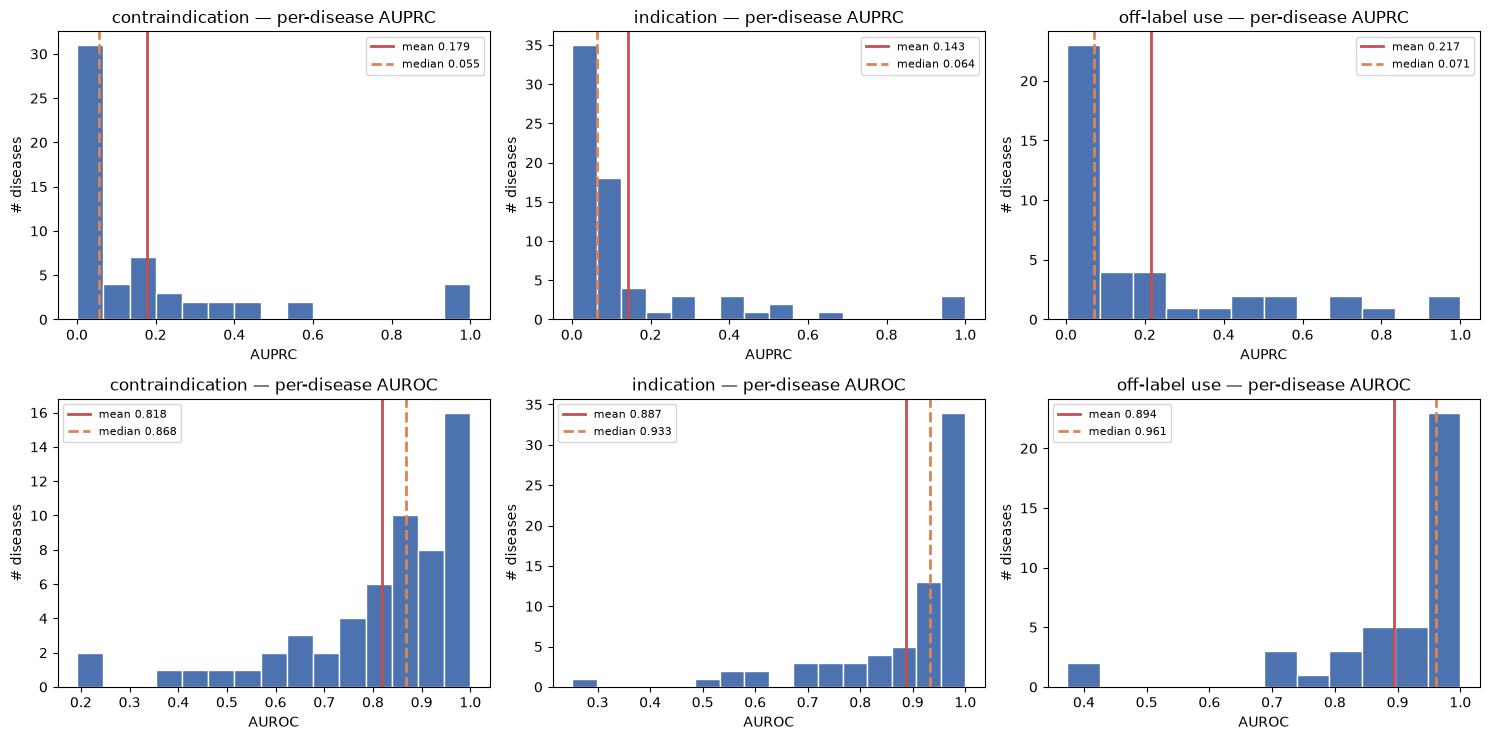

In [48]:
rels = list(summary_tables.keys())
fig, axes = plt.subplots(2, len(rels), figsize=(5 * len(rels), 7.5), squeeze=False)

for j, rel in enumerate(rels):
    df = disease_centric['rev_' + rel]
    for i, metric in enumerate(['AUPRC', 'AUROC']):
        v = pd.to_numeric(df[metric], errors='coerce')
        v = v[v != -1].dropna()
        ax = axes[i][j]
        ax.hist(v, bins=min(40, max(5, int(np.sqrt(len(v)) * 2))), color='#4C72B0', edgecolor='white')
        ax.axvline(v.mean(), color='#C44E52', lw=2, label='mean %.3f' % v.mean())
        ax.axvline(v.median(), color='#DD8452', lw=2, ls='--', label='median %.3f' % v.median())
        ax.set_title(f'{rel} — per-disease {metric}')
        ax.set_xlabel(metric); ax.set_ylabel('# diseases'); ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(RESULT_DIR / 'per_disease_distributions.png', dpi=150)
plt.show()

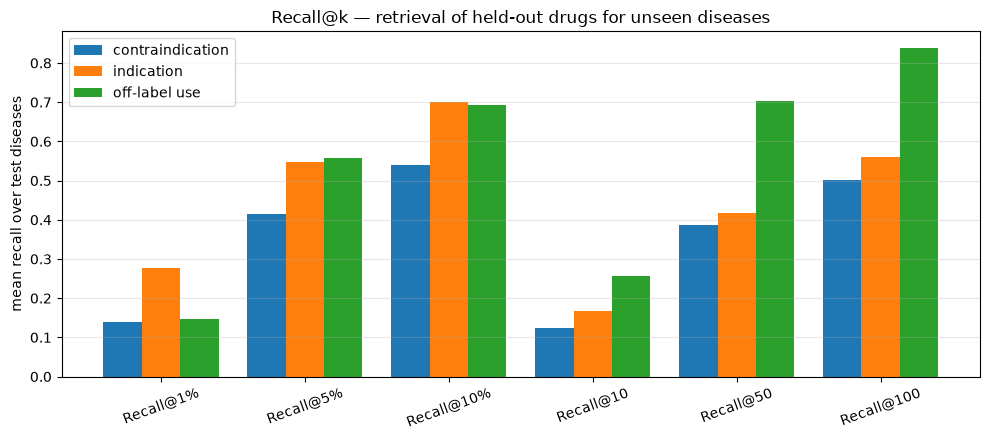

In [49]:
ks = ['Recall@1%', 'Recall@5%', 'Recall@10%', 'Recall@10', 'Recall@50', 'Recall@100']
avail = [k for k in ks if k in headline.index]

fig, ax = plt.subplots(figsize=(10, 4.5))
w = 0.8 / len(rels)
x = np.arange(len(avail))
for i, rel in enumerate(rels):
    ax.bar(x + i * w, headline.loc[avail, rel].values, width=w, label=rel)
ax.set_xticks(x + w * (len(rels) - 1) / 2)
ax.set_xticklabels(avail, rotation=20)
ax.set_ylabel('mean recall over test diseases')
ax.set_title('Recall@k — retrieval of held-out drugs for unseen diseases')
ax.legend(); ax.grid(axis='y', alpha=.3)
fig.tight_layout()
fig.savefig(RESULT_DIR / 'recall_at_k.png', dpi=150)
plt.show()

### 7.4 Reference numbers from the paper

All values below are **edge-level AUPRC** (§7.1) — the paper's evaluation builds one sampled negative per
positive ("creating counterparts for each positive pair", Methods), which is what `evaluate_fb` scores.

| Setting | Relation | TxGNN (paper) | Best baseline | Source |
|---|---|---|---|---|
| `random` split (Fig. 2c) | indication | **0.913** | 0.873 (HAN) | stated in text |
| `random` split (Fig. 2c) | contraindication | **~0.83** | ~0.845 (HAN) | read off Fig. 2c |
| **`complex_disease`** / zero-shot (Fig. 2d) | indication | **~0.89** | ~0.75 (BioBERT) | Fig. 2d; text gives +19.0% over best baseline |
| **`complex_disease`** / zero-shot (Fig. 2d) | contraindication | **~0.80** | ~0.645 (RGCN) | Fig. 2d; text gives +23.9% over best baseline |
| zero-shot, Explainer section | indication | 0.890 (s.d. 0.006) | — | stated in text — matches Fig. 2d |

The zero-shot absolutes are not written out in the body text, only plotted. They are recovered two ways
that agree: reading the TxGNN marker off Fig. 2d, and multiplying the visible best-baseline value by the
stated gain (0.75 × 1.190 = 0.893; 0.645 × 1.239 = 0.799). The Explainer section's independently-stated
`AUPRC = 0.890` for the full KG corroborates the indication figure.

`off-label use` is not benchmarked in the paper — TxGNN trains on it, but Fig. 2 reports only indication
and contraindication.

Caveats when comparing:

* The paper averages **5 random splits** and shows 95% CIs. Run §9 before claiming a match.
* Paper numbers are edge-level (§7.1). §7.2's per-disease ranking metrics correspond to the paper's
  Supplementary Figs. 9–11, whose raw values are not in this repo.
* The published model used the authors' Dataverse KG snapshot; `data/kg/` may differ. §3 prints yours.

In [50]:
# TxGNN's own edge-level AUPRC as reported in the paper, per split (see 7.4 for provenance).
# Random-split indication is stated in the text; the rest are read off Fig. 2c/2d and cross-checked
# against the stated gains over the best baseline. ~ marks a figure-read value.
PAPER_AUPRC = {
    'random':          {'indication': 0.913, 'contraindication': 0.83},
    'complex_disease': {'indication': 0.89,  'contraindication': 0.80},
}
ref = PAPER_AUPRC.get(CFG['split'], {})

comp = []
for rel in rels:
    mask = edge_level.relation.str.contains(f'--{rel}-->')
    ours = float(edge_level.loc[mask, 'AUPRC'].iloc[0]) if mask.any() else np.nan
    paper = ref.get(rel, np.nan)
    comp.append({
        'relation': rel,
        'this run - edge-level AUPRC': ours,
        'paper AUPRC (%s)' % CFG['split']: paper,
        'delta': ours - paper if paper == paper else np.nan,
        'this run - disease-centric AUPRC': headline.loc['AUPRC', rel],
        'this run - disease-centric AUROC': headline.loc['AUROC', rel],
    })

comp = pd.DataFrame(comp)
comp.to_csv(RESULT_DIR / 'comparison_vs_paper.csv', index=False)
display(comp.style.format('{:.4f}', subset=comp.columns[1:], na_rep='n/a'))

print()
print('split=%s, profile=%s, seed=%d' % (CFG['split'], CFG['profile'], CFG['seed']))
if CFG['profile'] == 'smoke':
    print('>>> SMOKE PROFILE - these numbers validate the plumbing only. <<<')
print('Compare the "edge-level" column against the paper. The disease-centric columns are a')
print('different quantity (ranking ~2k drugs, random baseline ~0.003) - see 7.4 and 11.6.')
print('n=1 seed here; the paper averages 5 splits with 95% CIs. Run 9 before claiming a match.')

,relation,this run - edge-level AUPRC,paper AUPRC (complex_disease),delta,this run - disease-centric AUPRC,this run - disease-centric AUROC
0,contraindication,0.7795,0.8000,-0.0205,0.1787,0.8182
1,indication,0.8769,0.8900,-0.0131,0.1432,0.8874
2,off-label use,0.8627,n/a,n/a,0.2167,0.8941



split=complex_disease, profile=full, seed=1
Compare the "edge-level" column against the paper. The disease-centric columns are a
different quantity (ranking ~2k drugs, random baseline ~0.003) - see 7.4 and 11.6.
n=1 seed here; the paper averages 5 splits with 95% CIs. Run 9 before claiming a match.


---
## 8 · Qualitative inspection

Metrics aside, the model's actual output is a ranked drug list per disease. This section pulls one out
with real drug and disease names.

In [51]:
maps = txdata.retrieve_id_mapping()   # id2name_drug, id2name_disease, idx2id_disease, idx2id_drug

def disease_name(idx):
    did = maps['idx2id_disease'].get(float(idx))
    return maps['id2name_disease'].get(did, f'<idx {idx}>')

QUERY_RELATION = 'indication'
test_disease_idxs = tx_eval.retrieve_disease_idxs_test_set(QUERY_RELATION)
print('%d test diseases available for "%s". First 10:' % (len(test_disease_idxs), QUERY_RELATION))
for idx in test_disease_idxs[:10]:
    print('   %10s  %s' % (idx, disease_name(idx)))

QUERY_DISEASE_IDX = float(test_disease_idxs[0])
print('\nquerying:', disease_name(QUERY_DISEASE_IDX))

71 test diseases available for "indication". First 10:
      13535.0  tinea pedis
      12508.0  tenosynovitis
      12622.0  atopic eczema
      15468.0  postmenopausal osteoporosis
       7189.0  autoimmune hemolytic anemia
      14126.0  parapsoriasis
      14048.0  acute respiratory distress syndrome
      13185.0  typhoid fever
      13446.0  osteitis fibrosa
       6462.0  monogenic obesity

querying: tinea pedis


In [52]:
raw = tx_eval.eval_disease_centric(
    disease_idxs   = [QUERY_DISEASE_IDX],
    relation       = QUERY_RELATION,
    save_result    = False,
    show_plot      = False,
    verbose        = False,
    return_raw     = True,      # -> {'prediction': {disease_id: {drug_id: score}}, 'label': ..., 'result': ...}
    simulate_random= False,
)

did    = list(raw['prediction'].keys())[0]
preds  = raw['prediction'][did]
labels = raw['label'][did]

rank = (pd.DataFrame({'drug_id': list(preds.keys()),
                      'score'  : list(preds.values()),
                      'label'  : [labels[k] for k in preds.keys()]})
          .assign(drug=lambda d: d.drug_id.map(maps['id2name_drug']))
          .query('label != -1')          # -1 == known positive already in train/valid
          .sort_values('score', ascending=False)
          .reset_index(drop=True))
rank.index += 1

print('disease : %s  (id %s)' % (disease_name(QUERY_DISEASE_IDX), did))
print('relation: %s | candidates ranked: %d | held-out positives: %d\n'
      % (QUERY_RELATION, len(rank), int((rank.label == 1).sum())))

print('--- top 25 predicted drugs  (* = held-out ground-truth positive) ---')
top = rank.head(25)[['drug', 'score', 'label']].copy()
top['hit'] = np.where(top.label == 1, '*', '')
display(top[['drug', 'score', 'hit']].style.format({'score': '{:.4f}'}))

print('\n--- where the held-out positives actually landed ---')
display(rank[rank.label == 1][['drug', 'score']].head(20).style.format({'score': '{:.4f}'}))

  0%|          | 0/1 [00:00<?, ?it/s]

disease : tinea pedis  (id 5984.0)
relation: indication | candidates ranked: 7957 | held-out positives: 24

--- top 25 predicted drugs  (* = held-out ground-truth positive) ---


,drug,score,hit
1,Difluprednate,4.0046,
2,Doxycycline,3.5039,
3,Miconazole,3.2253,*
4,Ciprofloxacin,3.2115,
5,Acetic acid,3.1763,
6,Chlortetracycline,3.1563,
7,Chlorhexidine,3.1078,
8,Lodoxamide,3.0290,
9,Terbinafine,3.0198,*
10,Fluorometholone,2.9394,



--- where the held-out positives actually landed ---


,drug,score
3,Miconazole,3.2253
9,Terbinafine,3.0198
17,Clioquinol,2.7201
28,Luliconazole,2.3942
31,Ketoconazole,2.3712
48,Oxiconazole,2.0862
49,Zinc oxide,2.0802
50,Clotrimazole,2.0652
60,Undecylenic acid,1.8857
63,Pramocaine,1.8360


### 8.1 Nearest diseases in signature space

`retrieve_sim_diseases` exposes the metric-learning module directly: for each disease with edges of the
given relation, the `k` most similar diseases by signature-vector cosine similarity. These are the
diseases whose embeddings get pooled into a zero-shot query — i.e. the model's own answer to *"what is
this disease like?"*.

Two things to know: it reads `self.model`, not `self.best_model`, and it recomputes node embeddings, so
it costs one extra full-graph forward.

In [53]:
from torch_geometric.utils import degree

SIM_RELATION = 'indication'
sim_k        = 5
etype        = ('disease', 'rev_' + SIM_RELATION, 'drug')

sim_diseases = model.retrieve_sim_diseases(relation=SIM_RELATION, k=sim_k)   # [n_query, k] disease indices

# row i of `sim_diseases` corresponds to the i-th disease with out-degree > 0 for `etype`
G_cpu   = model.G.to('cpu')
out_deg = degree(G_cpu[etype].edge_index[0], num_nodes=G_cpu['disease'].num_nodes)
query_idxs = torch.where(out_deg != 0)[0]

rows = []
for i in range(min(10, sim_diseases.shape[0])):
    rows.append({'disease': disease_name(int(query_idxs[i])),
                 'most similar diseases': ' | '.join(disease_name(int(j)) for j in sim_diseases[i])})
display(pd.DataFrame(rows))

,disease,most similar diseases
0,anaphylaxis,autoimmune disease | situs inversus | nephropa...
1,nephropathic cystinosis,autosomal recessive familial Mediterranean fev...
2,Waldenstrom macroglobulinemia,hypoalphalipoproteinemia | aromatase excess sy...
3,situs inversus,Marfan syndrome | monosomy X | Turner syndrome...
4,Sjogren syndrome,dry eye syndrome | polymyalgia rheumatica | Sc...
5,malignant glioma,gliosarcoma | glioma | oligoastrocytoma | gian...
6,carcinoid syndrome,adrenal gland pheochromocytoma | sympathetic p...
7,tardive dyskinesia (disease),"hypogonadism, male | Peyronie disease | tricus..."
8,thrombocytopenia,"chronic eosinophilic leukemia, not otherwise s..."
9,thyrotoxicosis,Graves disease | hyperthyroidism | monosomy X ...


---
## 9 · Multi-seed reproduction (5 splits)

The paper reports mean ± 95% CI over **5 random data splits**. A single run is not comparable to a
published number. This cell reruns data → model → pretrain → finetune → disease-centric eval for each
seed and aggregates.

Cost is ~5× §3–§7. Set `RUN_MULTISEED = True` in §2 and expect a multi-day job at the `full` profile.
Each seed writes its own `results/<run>/` directory, so the loop is resumable — completed seeds are skipped.

> **Before enabling this**, free the single-seed run's GPU memory — the `model` from §4–§6 still holds a
> full copy of the graph on the device:
> ```python
> del model, tx_eval; torch.cuda.empty_cache()
> ```
> Cleanest is to restart the kernel and run §1, §2 (with `RUN_MULTISEED = True`), §3's data-wiring cell,
> and the `summarise` definition cell in §7.2 — then this one. Projected cost at the `full` profile on the
> box in §0: **~5–8 h** for 5 seeds. Seeds already on disk are skipped, so the loop is resumable.


In [54]:
SEEDS = [1, 2, 3, 4, 5]

def run_one_seed(seed, profile=PROFILE, split=SPLIT):
    run_name = f'TxGNN_{split}_seed{seed}_{profile}'
    rdir = REPO_ROOT / 'results' / run_name
    out_csv = rdir / 'disease_centric_summary.csv'
    if out_csv.exists():
        print(f'[seed {seed}] cached -> {out_csv}')
        return pd.read_csv(out_csv, index_col=0)

    rdir.mkdir(parents=True, exist_ok=True)
    mdir = REPO_ROOT / 'saved_models' / run_name
    mdir.mkdir(parents=True, exist_ok=True)
    prof = _PROFILES[profile]

    print(f'\n{"#"*78}\n# seed {seed}\n{"#"*78}')
    set_all_seeds(seed)
    d = TxData(data_folder_path=str(DATA_FOLDER))
    d.prepare_split(split=split, seed=seed, no_kg=False)

    set_all_seeds(seed)
    m = TxGNN(data=d, weight_bias_track=False, exp_name=run_name, device=DEVICE)
    m.model_initialize(**MODEL_CFG)

    if prof['pretrain']['n_epoch'] > 0:
        set_all_seeds(seed); m.pretrain(**prof['pretrain'])
    set_all_seeds(seed); m.finetune(**prof['finetune'])
    m.save_model(str(mdir))

    ev = TxEval(model=m)
    if prof['eval']['n_diseases'] is None:
        dc = ev.eval_disease_centric(disease_idxs='test_set', relation=None, save_result=True,
                                     save_name=str(rdir / 'disease_centric_eval.pkl'),
                                     show_plot=False, verbose=False, return_raw=False,
                                     simulate_random=prof['eval']['simulate_random'])
    else:
        dc = {}
        for rel in DD_REL:
            idxs = ev.retrieve_disease_idxs_test_set(rel)[:prof['eval']['n_diseases']]
            dc['rev_' + rel] = ev.eval_disease_centric(disease_idxs=list(idxs), relation=rel,
                                                       save_result=False, show_plot=False, verbose=False,
                                                       return_raw=False,
                                                       simulate_random=prof['eval']['simulate_random'])

    tbl = pd.DataFrame({r.replace('rev_', ''): summarise(df)['mean'] for r, df in dc.items()})
    tbl.to_csv(out_csv)

    del m, d, ev, dc
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return tbl


if RUN_MULTISEED:
    per_seed = {s: run_one_seed(s) for s in SEEDS}

    stacked = pd.concat(per_seed, names=['seed'])
    agg = stacked.groupby(level=1).agg(['mean', 'std', 'count'])

    ci = {}
    for rel in per_seed[SEEDS[0]].columns:
        m_ = agg[(rel, 'mean')]; s_ = agg[(rel, 'std')]; n_ = agg[(rel, 'count')]
        ci[rel] = m_.round(4).astype(str) + ' ± ' + (1.96 * s_ / np.sqrt(n_)).round(4).astype(str)
    ci = pd.DataFrame(ci)

    ci.to_csv(REPO_ROOT / 'results' / f'multiseed_{SPLIT}_{PROFILE}.csv')
    print(f'\nmean ± 95% CI over {len(SEEDS)} splits — disease-centric metrics')
    display(ci.loc[[i for i in ['AUPRC', 'AUROC', 'Recall@1%', 'Recall@5%', 'Recall@10%',
                                'MRR@50', 'AP@50'] if i in ci.index]])
else:
    print('RUN_MULTISEED is False — single-seed results only (see §2 to enable).')

RUN_MULTISEED is False — single-seed results only (see §2 to enable).


---
## 10 · TxGNN Explainer (GraphMask) — optional

Post-hoc, *learned* edge sparsification. For each relation and each of the 2 layers, a small gate network
(hard-concrete relaxation, `txgnn/graphmask/`) decides whether a message survives; suppressed messages are
replaced by a learned baseline vector. The objective is Lagrangian: **minimise the number of retained
edges subject to the prediction staying within `allowance` of the unmasked prediction.** Layers are
enabled one at a time, `epochs_per_layer` each.

The paper's claim from this module: keeping only edges with importance > 0.5 (14.9 % of the KG) moves
AUPRC from 0.890 → 0.886, while keeping only the *other* 85.1 % drops it to 0.628.

Cost: `2 × epochs_per_layer` full-graph forward+backward passes — comparable to the whole of §6.
Enable with `RUN_EXPLAINER = True` in §2.

In [55]:
if RUN_EXPLAINER:
    EXPLAIN_RELATION = 'indication'

    t0 = time.time()
    gm_metrics = model.train_graphmask(
        relation                 = EXPLAIN_RELATION,
        learning_rate            = 3e-4,
        allowance                = 0.005,
        epochs_per_layer         = CFG['explainer']['epochs_per_layer'],
        penalty_scaling          = 1,
        moving_average_window_size = 100,
        valid_per_n              = CFG['explainer']['valid_per_n'],
    )
    print('\ngraphmask training took %.1f min' % ((time.time() - t0) / 60))
    print(gm_metrics)

    model.save_graphmask_model(str(MODEL_DIR / 'graphmask'))
    with open(RESULT_DIR / f'graphmask_metrics_{EXPLAIN_RELATION}.json', 'w') as f:
        json.dump({k: float(v) for k, v in gm_metrics.items()}, f, indent=2)
else:
    print('RUN_EXPLAINER is False — skipping GraphMask.')

RUN_EXPLAINER is False — skipping GraphMask.


In [56]:
if RUN_EXPLAINER:
    # D11: TxGNN.retrieve_save_gates(path) calls retrieve_gates_scores_penalties() with no
    # arguments, but that method requires `relation` -> TypeError. Call it directly instead
    # and do the id->name join here.
    whole_graph, test_graph = model.retrieve_gates_scores_penalties(EXPLAIN_RELATION)
    _, _, _, _, num_masked, gates, scores, penalties = whole_graph

    df_raw = pd.read_csv(DATA_FOLDER / 'kg.csv')
    from txgnn.utils import convert2str
    df_raw['x_id'] = df_raw.x_id.apply(convert2str)
    df_raw['y_id'] = df_raw.y_id.apply(convert2str)
    dfm = model.df.copy()
    dfm['x_id'] = dfm.x_id.apply(convert2str)
    dfm['y_id'] = dfm.y_id.apply(convert2str)

    idx2id, id2name = {}, {}
    for nt in model.G.node_types:
        m_ = dict(dfm[dfm.x_type == nt][['x_idx', 'x_id']].values)
        m_.update(dict(dfm[dfm.y_type == nt][['y_idx', 'y_id']].values))
        idx2id[nt] = m_
        n_ = dict(df_raw[df_raw.x_type == nt][['x_id', 'x_name']].values)
        n_.update(dict(df_raw[df_raw.y_type == nt][['y_id', 'y_name']].values))
        id2name[nt] = n_

    G_cpu = model.G.to('cpu')
    parts = []
    for (src, rel, dst) in G_cpu.edge_types:
        ei = G_cpu[(src, rel, dst)].edge_index
        t = pd.DataFrame({'x_idx': ei[0].numpy(), 'y_idx': ei[1].numpy()})
        t['x_name'] = t.x_idx.map(lambda v: id2name[src].get(idx2id[src].get(v)))
        t['y_name'] = t.y_idx.map(lambda v: id2name[dst].get(idx2id[dst].get(v)))
        t['x_type'], t['y_type'], t['relation'] = src, dst, rel
        if rel not in scores[0] or rel not in scores[1]:
            continue                      # relation carried no gated messages
        t['layer1_importance'] = scores[0][rel].numpy().reshape(-1)
        t['layer2_importance'] = scores[1][rel].numpy().reshape(-1)
        parts.append(t)

    gates_df = pd.concat(parts, ignore_index=True)
    gates_df.to_pickle(RESULT_DIR / f'graphmask_edge_importance_{EXPLAIN_RELATION}.pkl')

    print('edges scored: %s' % f'{len(gates_df):,}')
    print('fraction with layer-2 importance > 0.5: %.1f%%'
          % (100 * (gates_df.layer2_importance > 0.5).mean()))
    display(gates_df.nlargest(20, 'layer2_importance')[
        ['x_name', 'relation', 'y_name', 'layer1_importance', 'layer2_importance']])

---
## 11 · Design decisions and known rough edges

Two kinds of thing live here: **decisions I made** (D-numbers, forced by an actual gap) and **properties
of the port** you should know before trusting or timing a run. No file under `pyg_implementation/` was
modified.

### 11.1 Pretraining is much slower than the DGL original — documented, not patched (D10)

`TxGNN.pretrain()` differs from `dgl_implementation` in three ways:

1. It materialises **every edge as a Python tuple**:
   ```python
   for etype in self.G.edge_types:
       ei = self.G[etype].edge_index
       for i in range(ei.shape[1]):
           all_edges.append((etype, ei[0, i].item(), ei[1, i].item()))
   ```
   For ~8 M edges that is a few minutes and roughly 1 GB of RAM before the first gradient step.
2. Message passing runs over the **entire graph** every mini-batch, where DGL used
   `MultiLayerFullNeighborSampler(2)` blocks. Full-neighbour sampling is *exact*, so the scores are
   numerically equivalent — but the block version only computes the sub-graph the batch needs.
3. `self.G.to(self.device)` is called **inside the step loop** while `self.G` stays on CPU, so the whole
   graph is re-copied host→device on every step.

None of this is fixed here. A vectorised rewrite would change RNG consumption and batch composition, and
therefore the numbers — which defeats the purpose of a reproduction notebook. If you do rewrite it, treat
the result as a different experiment. The cost probe in §4.2 gives you the real number for your hardware.

### 11.2 `model_initialize(proto=True)` is memory- and time-hungry

`DistMultPredictor.__init__` calls `obtain_disease_profile` once per disease per drug–disease relation,
and each call boolean-masks a full `edge_index`. It then stacks the profiles (|diseases| × |disease| +
|gene/protein| floats) and forms a dense |D| × |D| similarity matrix per relation, kept for the model's
lifetime — the "similarity matrices built for" list printed in §4.1.

**Measured on full PrimeKG: 3.2 s, 22 MB of similarity matrices** — far cheaper than the quadratic form
suggests, because |D| is the number of diseases *with drug edges in the training graph* (618–1,124 per
relation), not all 17,080 diseases. Watch this if you move to a split that keeps many more treated
diseases in train, or to `sim_measure='all_nodes_profile_more'`, which widens the profile vector to
phenotypes and exposures.

### 11.3 Disease-centric evaluation is one full-graph forward per disease

`utils.get_scores_disease` builds a fresh `HeteroData` with one disease against all ~8 k drugs and calls
`model(G, g_eval, g_eval, ...)` — a complete forward pass — for **each** disease, for **each** relation.
This dominates total runtime at the `full` profile. It is also why §7.2 has a `n_diseases` knob.

A second, easily-missed cost: `disease_centric_evaluation` re-reads the ~1 GB `kg.csv` from disk on
**every call**, only to build the id→name maps. `disease_idxs='test_set'` handles all three relations in
one call and pays that once; the per-relation subset loop used by `smoke` pays it three times — which is
most of the 0.8 min the smoke run spent on 15 diseases. The true per-disease cost is nearer 0.8 s.

### 11.4 Library bugs worked around in this notebook

| Where | Problem | Workaround |
|---|---|---|
| `TxGNN.retrieve_save_gates(path)` | calls `self.retrieve_gates_scores_penalties()` with no args; the method requires `relation` → `TypeError` | §10 calls `retrieve_gates_scores_penalties(relation)` directly and does the id→name join in the notebook (**D11**) |
| `utils.summary(show_plot=True)` | `sns.scatterplot(list, list)` / `sns.distplot` — removed from seaborn ≥ 0.12 | `show_plot=False`; plots redrawn in §7.3 (**D5**) |
| `TxData.__init__` | downloads `node.csv` (singular) but PrimeKG ships `nodes.csv`; `DataSplitter` also expects it **tab**-separated | §3 rewrites `data/kg/nodes.csv` → `data/node.csv` as TSV (**D1**) |
| `TxGNN.save_model` / `load_pretrained` | `self.config` omits `exp_lambda`, so a reload silently falls back to the default `0.7` | harmless at the default used here; change `exp_lambda` and you must set it again by hand after `load_pretrained` |
| `TxGNN.finetune` | uses the deprecated `torch.nn.init.xavier_uniform` | warning only |
| `utils.get_all_metrics` | references a module-level `edge_dict` that is never defined | function is unused on this path |

### 11.5 What "reproducible" means here (D4)

Bit-exact reproduction is **not** achievable, and pretending otherwise would be the real error:

* `txgnn/TxGNN.py` calls `torch.manual_seed(0)` at *import* time, so RNG state depends on import order.
* Node embeddings are Xavier-random **and frozen** (`requires_grad=False`) — they are never trained, so
  the draw itself is part of the model. A different seed is a different model.
* Negative sampling (`Full_Graph_NegSampler`, `Minibatch_NegSampler`) redraws every step.
* `Enrichment@k` / `Recall_Random@k` use 500 **unseeded** `np.random.shuffle` calls per disease (**D12**).
* `scatter(reduce='mean')` is non-deterministic on CUDA (atomic float order), so even a fixed seed drifts.

What the notebook does instead: seeds every RNG before each stage, records the exact config and library
versions in `results/<run>/run_config.json`, and reports **mean ± 95% CI over 5 splits** in §9 — which is
what the paper reports and what is actually comparable.

### 11.6 Two metric families, one name (D7, D8)

"AUPRC" means different things in §7.1 and §7.2, and I initially had the mapping backwards.

**The paper's headline AUPRC is the edge-level one (§7.1).** Methods: negatives are made by "creating
counterparts for each positive pair" — 1 negative per positive. Against that balanced set a random model
scores 0.5, which is the scale the paper's 0.87–0.91 values live on. §7.2 instead ranks ~2,000 candidate
drugs per disease against a handful of positives; its random baseline is ~0.003, so per-disease AUPRC of
0.13–0.21 is *strong*, not weak — read `Enrichment@k` (12–24× random here) to see it on an interpretable
scale. Comparing §7.2's AUPRC to 0.913 is a category error.

Within §7.2, `utils.calculate_metrics` writes `-1` for a disease with no usable positives while
`utils.summary()` averages those in, so §7.2 prints both the library's number and the sentinel-filtered one.

### 11.7 Fidelity of the port itself

Verified against the DGL implementation in `dgl_benchmark.ipynb` / `pyg_benchmark.ipynb` /
`compare_results.ipynb`: graph construction (node/edge counts and sorted edge indices per type),
forward-pass parity with DGL weights loaded into the PyG model, and disease-centric AUROC on a sample.
`PYG_REFACTOR.md` has the full DGL→PyG API mapping. The mathematical substitutions that matter:

* `multi_update_all(copy_u + mean, 'sum')` → `torch_scatter.scatter(reduce='mean')` accumulated per etype
* `dgl.ops.edge_softmax` → `torch_geometric.utils.softmax` (attention path only, `attention=True`)
* `G.local_scope()` → plain local dicts; nothing is stashed on the graph during a forward pass
* `apply_edges(udf)` → direct indexing `h[src][ei[0]] * w_r * h[dst][ei[1]]`

---
## 12 · Reproduction checklist

1. **Environment** — torch + `torch-geometric` + `torch-scatter` built against the *same* CUDA. §1 prints
   all three; a mismatch shows up as an import error or silently wrong `scatter` results.
2. **Data** — `data/kg/kg.csv` present (or let §3 download). Confirm the node/edge counts §3 prints are
   what you expect; a different PrimeKG snapshot gives different numbers throughout.
3. **Smoke first** — `PROFILE = 'smoke'`, run every cell top to bottom. Roughly 15 min. This catches
   version and path problems before a multi-hour job.
4. **Cost probe** — §4.2, then decide whether the `full` schedule fits your budget.
5. **Full run** — `PROFILE = 'full'`, restart the kernel, run top to bottom. Pretraining must not be
   skipped.
6. **Confidence intervals** — `RUN_MULTISEED = True`, seeds 1–5. Only now compare against the paper.
7. **Report** from `results/<run_name>/`:
   * `disease_centric_summary.csv` — the headline numbers
   * `edge_level_test_metrics.csv` — training-loop diagnostic
   * `run_config.json` — exact config + library versions
   * `multiseed_<split>_<profile>.csv` — mean ± 95% CI

**Ablations**, all via `MODEL_CFG` in §2 — the same ones `reproduce/train.py` exposes:

| Variant | Change |
|---|---|
| `GNN` (no metric learning) | `proto=False` |
| `TxGAT` (attention encoder) | `attention=True` |
| No-KG | `TxData.prepare_split(..., no_kg=True)`; pretraining becomes impossible and `proto` is force-disabled |
| Other zero-shot protocols | `SPLIT = 'random'`, `'complex_disease_cv'`, or any of the 9 disease areas |
| Disease-area holdouts | `SPLIT = 'cardiovascular'` etc. — needs `data/node.csv` + `data/edges.csv` (§3 creates them) |